# Rwanda Firm Activity

## Requirements

In [ ]:

# SETUP: Install and import dependencies


!pip install rasterio geopandas --quiet
!sudo apt-get install -y gdal-bin

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

# For nicer plots
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-gdal python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-dev python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 6 not upgraded.
Need to get 5,168 kB of archives.
After this operation, 25.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.8.4+dfsg-1~jammy0 [605 kB]
Fetched 5,168 kB in 6s (891 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is 

In [ ]:

# GOOGLE DRIVE MOUNT (for persistence)

from google.colab import drive
drive.mount('/content/drive')

# Define project path in your Drive
PROJECT_PATH = "/content/drive/MyDrive/rwanda-nightlights-firm-activity"

os.makedirs(PROJECT_PATH, exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/data/raw", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/data/processed", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/outputs/maps", exist_ok=True)

print("Folders created.")

Mounted at /content/drive
Folders created.


In [7]:
# INSTALL + AUTHENTICATE GEE
# Need a google cloud project + google earth engine api enabled + project registered to use api

!pip install earthengine-api geemap --quiet

import ee
import geemap
import os
import time

ee.Authenticate()
ee.Initialize(project="nightlights-project-123456")  # your project ID

print("Earth Engine initialized.")

Earth Engine initialized.


## Download data


In [19]:
# =========================================
# DEFINE RWANDA BOUNDING BOX (COORDINATES)
# =========================================

# Rwanda bounding box (clean, no shapefile dependency)
rwanda_bbox = ee.Geometry.Rectangle([
    28.8,   # min lon
    -2.9,   # min lat
    30.9,   # max lon
    -1.0    # max lat
])


# =========================================
# LOAD MOST RECENT VIIRS DATA (V22)
# =========================================

# 👉 latest available year (2023 or 2024 depending on catalog)
dataset = ee.ImageCollection("NOAA/VIIRS/DNB/ANNUAL_V22") \
            .sort("system:time_start", False) \
            .first()

# Select correct band
image = dataset.select("average").clip(rwanda_bbox)


# =========================================
# EXPORT (DIRECT DOWNLOAD)
# =========================================

OUTPUT_PATH = f"{PROJECT_PATH}/data/raw/nightlights_2022.tif"

print("Downloading latest VIIRS V22 data (Rwanda bbox)...")

geemap.ee_export_image(
    image,
    filename=OUTPUT_PATH,
    scale=500,
    region=rwanda_bbox,
    file_per_band=False
)

print("Download complete:", OUTPUT_PATH)


# =========================================
# LOAD RASTER (UNCHANGED)
# =========================================

with rasterio.open(OUTPUT_PATH) as src:
    nightlights = src.read(1)
    profile = src.profile

print("Raster loaded.")
print("Shape:", nightlights.shape)
print("Min:", np.min(nightlights))
print("Max:", np.max(nightlights))

Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2022.tif
Download complete: /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2022.tif
Raster loaded.
Shape: (424, 469)
Min: -1.5
Max: 3786.3926


In [20]:
# VERIFY DOWNLOADED FILE

import os

file_path = OUTPUT_PATH

if os.path.exists(file_path):
    file_size_bytes = os.path.getsize(file_path)
    file_size_mb = file_size_bytes / (1024 * 1024)
    print(f"File exists at: {file_path}")
    print(f"File size: {file_size_mb:.2f} MB")

    # Attempt to get gdalinfo (requires GDAL to be installed, which rasterio generally uses)
    print("\nRunning gdalinfo to inspect the TIFF file:")
    !gdalinfo {file_path}

else:
    print(f"Error: File not found at {file_path}")
    print("Please ensure the download cell was executed successfully.")

File exists at: /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2022.tif
File size: 0.66 MB

Running gdalinfo to inspect the TIFF file:
Driver: GTiff/GeoTIFF
Files: /content/drive/MyDrive/rwanda-nightlights-firm-activity/data/raw/nightlights_2022.tif
Size is 469, 424
Coordinate System is:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geo

In [21]:

# LOAD RASTER DATA

with rasterio.open(OUTPUT_PATH) as src:
    nightlights = src.read(1)
    profile = src.profile

print("Raster loaded.")
print("Shape:", nightlights.shape)
print("Min value:", np.min(nightlights))
print("Max value:", np.max(nightlights))

Raster loaded.
Shape: (424, 469)
Min value: -1.5
Max value: 3786.3926


In [22]:

# CLEAN DATA

# Remove negative values (sensor noise)
nightlights_clean = np.where(nightlights < 0, 0, nightlights)

print("Cleaned data:")
print("Min:", np.min(nightlights_clean))
print("Max:", np.max(nightlights_clean))

Cleaned data:
Min: 0.0
Max: 3786.3926


In [23]:

# NORMALIZATION

nightlights_norm = (nightlights_clean - np.min(nightlights_clean)) / (
    np.max(nightlights_clean) - np.min(nightlights_clean)
)

print("Normalized data range:")
print("Min:", np.min(nightlights_norm))
print("Max:", np.max(nightlights_norm))

Normalized data range:
Min: 0.0
Max: 1.0


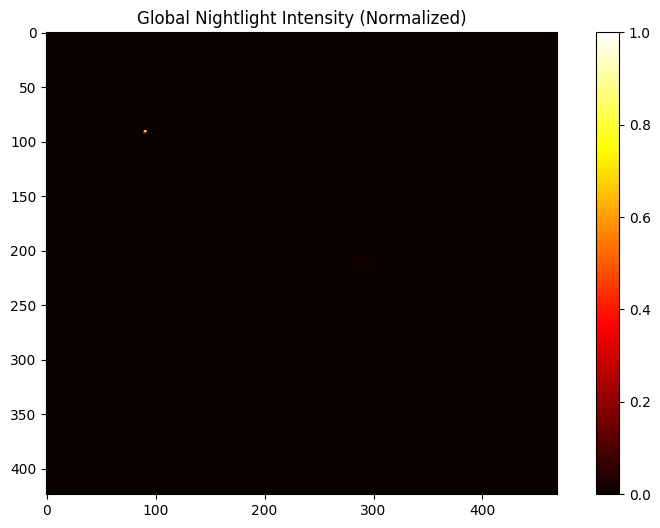

In [24]:
# VISUALIZE NIGHTLIGHTS

plt.imshow(nightlights_norm, cmap='hot')
plt.title("Global Nightlight Intensity (Normalized)")
plt.colorbar()
plt.show()

/tmp/ipykernel_46262/3850618837.py:7: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(rwanda_crop, cmap='hot')
/tmp/ipykernel_46262/3850618837.py:7: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(rwanda_crop, cmap='hot')


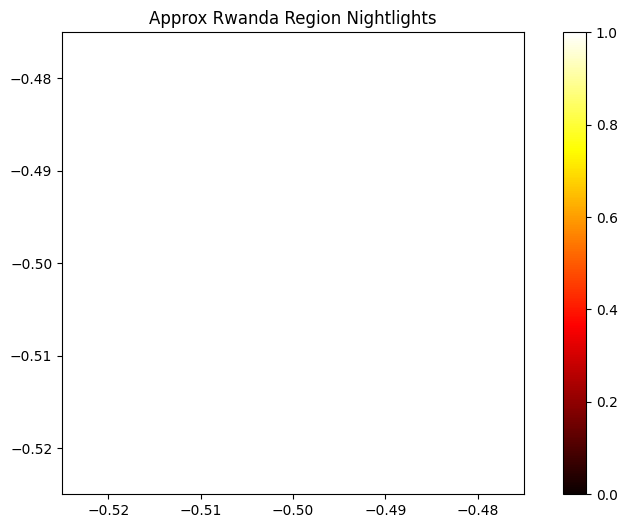

In [25]:
# ROUGH CROPPING (AFRICA / RWANDA REGION)
# NOTE: This is approximate (no shapefile yet) WORK STILL ONGOING

# These indices are approximate — refine later
rwanda_crop = nightlights_norm[2500:3000, 3000:3500]

plt.imshow(rwanda_crop, cmap='hot')
plt.title("Approx Rwanda Region Nightlights")
plt.colorbar()
plt.show()

In [26]:
# SUMMARY STATS

mean_intensity = np.mean(rwanda_crop)
max_intensity = np.max(rwanda_crop)
non_zero_pixels = np.sum(rwanda_crop > 0)

print("Rwanda Region Stats:")
print("Mean intensity:", mean_intensity)
print("Max intensity:", max_intensity)
print("Active pixels:", non_zero_pixels)

ValueError: zero-size array to reduction operation maximum which has no identity

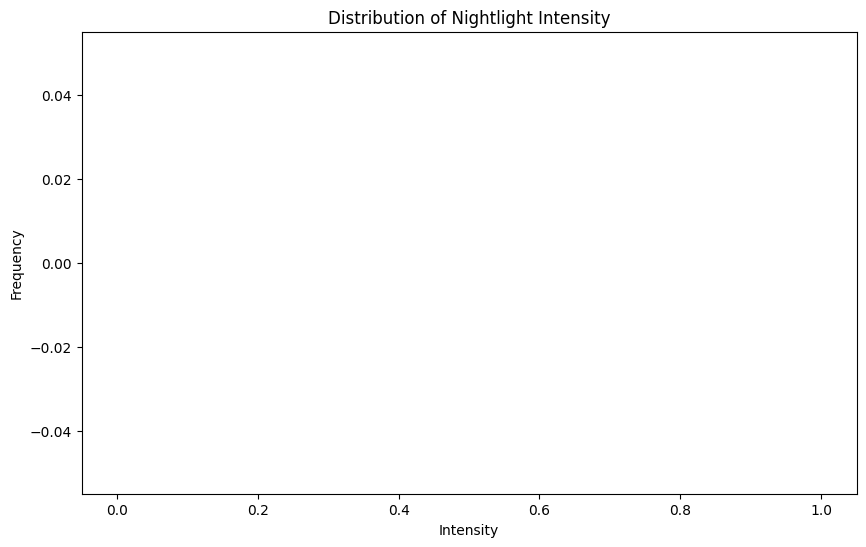

In [27]:
# DISTRIBUTION ANALYSIS

plt.hist(rwanda_crop.flatten(), bins=50)
plt.title("Distribution of Nightlight Intensity")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

In [28]:

# SAVE CLEAN DATA

np.save(f"{PROJECT_PATH}/data/processed/nightlights_rwanda.npy", rwanda_crop)

print("Processed data saved.")

Processed data saved.


/tmp/ipykernel_46262/1396839313.py:3: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(rwanda_crop, cmap='hot')
/tmp/ipykernel_46262/1396839313.py:3: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(rwanda_crop, cmap='hot')


Map saved at: /content/drive/MyDrive/rwanda-nightlights-firm-activity/outputs/maps/rwanda_nightlights.png


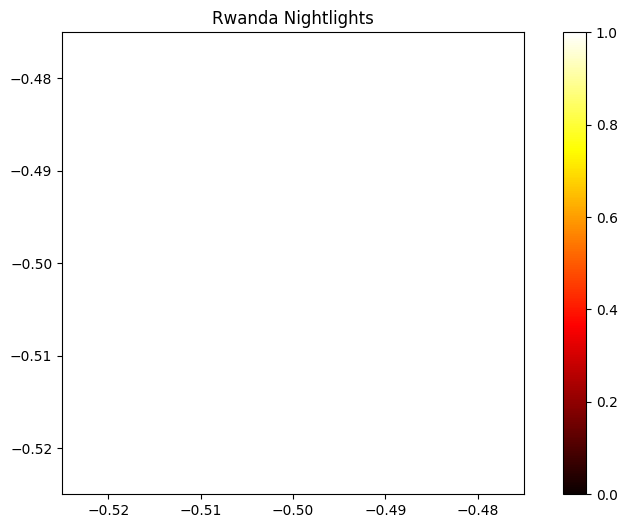

In [29]:

# SAVE MAP IMAGE

plt.imshow(rwanda_crop, cmap='hot')
plt.title("Rwanda Nightlights")
plt.colorbar()

output_path = f"{PROJECT_PATH}/outputs/maps/rwanda_nightlights.png"
plt.savefig(output_path)

print(f"Map saved at: {output_path}")

Next steps:

1.   Use better data
2.   2014 → 2023 nightlights (VIIRS yearly series)
2.   Proper Rwanda shapefile clipping (geopandas)
2.   K-means clustering → detect firm clusters
3.   Time series (multi-year lights)
4.   Merge with survey data (EICV proxy)